In [1]:
# ============================================================
# STUDENT PLACEMENT PREDICTION USING LOGISTIC REGRESSION
# ============================================================

# Import required libraries
import pandas as pd                  # For data manipulation
import numpy as np                   # For numerical operations
import matplotlib.pyplot as plt      # For plotting graphs
import seaborn as sns                # For advanced visualizations

# Machine Learning Libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load the dataset
df = pd.read_csv("train.csv")

# Display first five rows
df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [3]:
# Display last five rows
df.tail()

# Display shape of dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (45000, 15)

Column Names:
Index(['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA',
       'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
       'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications',
       'Backlogs', 'Placement_Status'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  i

In [4]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Fill missing numerical values with mean (if any)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Check again
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())

Missing Values:

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

Missing Values After Cleaning:

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64


In [5]:
# Summary statistics
print("Summary Statistics")
df.describe()

Summary Statistics


,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,24977.962600,20.999333,7.002290,0.774089,3.734222,5.691800,5.501644,69.385356,5.501644,1.800956,0.888133
std,14425.605704,1.995071,0.993855,0.844750,0.923738,1.994674,1.515374,13.909710,1.238722,0.650104,0.970954
min,1.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,12509.750000,19.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,24957.500000,21.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,5.000000,2.000000,1.000000
75%,37475.250000,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,50000.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


In [6]:
# Create LabelEncoder object
le = LabelEncoder()

# Convert categorical columns into numerical values
df['Gender'] = le.fit_transform(df['Gender'])
df['Degree'] = le.fit_transform(df['Degree'])
df['Branch'] = le.fit_transform(df['Branch'])
df['Placement_Status'] = le.fit_transform(df['Placement_Status'])

# If Internships column contains Yes/No values, encode it.
# If it already contains numbers, this line won't affect it much.
if df['Internships'].dtype == 'object':
    df['Internships'] = le.fit_transform(df['Internships'])

# Display first five rows after encoding
print("Dataset after Label Encoding:")
df.head()

Dataset after Label Encoding:


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,0,1,2,6.29,0,3,4,6,51,5,1,3,0
1,37820,20,0,2,2,6.05,1,4,6,8,59,8,2,1,0
2,49668,22,1,3,4,7.22,1,4,6,6,58,6,2,2,0
3,19467,22,1,3,4,7.78,2,4,6,6,90,4,2,0,1
4,23094,20,0,1,4,7.63,1,4,6,5,79,6,2,0,1


In [7]:
# Summary statistics
print("Summary Statistics")
display(df.describe())

# Number of placed and not placed students
print("\nPlacement Status Count:")
print(df['Placement_Status'].value_counts())

# Average CGPA based on Placement Status
print("\nAverage CGPA by Placement Status:")
print(df.groupby('Placement_Status')['CGPA'].mean())

# Average Coding Skills based on Placement Status
print("\nAverage Coding Skills by Placement Status:")
print(df.groupby('Placement_Status')['Coding_Skills'].mean())

# Average Aptitude Score based on Placement Status
print("\nAverage Aptitude Score by Placement Status:")
print(df.groupby('Placement_Status')['Aptitude_Test_Score'].mean())

Summary Statistics


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,24977.962600,20.999333,0.497333,1.494889,2.002244,7.002290,0.774089,3.734222,5.691800,5.501644,69.385356,5.501644,1.800956,0.888133,0.362489
std,14425.605704,1.995071,0.499998,1.120933,1.415084,0.993855,0.844750,0.923738,1.994674,1.515374,13.909710,1.238722,0.650104,0.970954,0.480724
min,1.000000,18.000000,0.000000,0.000000,0.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000,0.000000
25%,12509.750000,19.000000,0.000000,0.000000,1.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000,0.000000
50%,24957.500000,21.000000,0.000000,1.000000,2.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,5.000000,2.000000,1.000000,0.000000
75%,37475.250000,23.000000,1.000000,3.000000,3.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000,1.000000
max,50000.000000,24.000000,1.000000,3.000000,4.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000,1.000000



Placement Status Count:
Placement_Status
0    28688
1    16312
Name: count, dtype: int64

Average CGPA by Placement Status:
Placement_Status
0    6.633941
1    7.650109
Name: CGPA, dtype: float64

Average Coding Skills by Placement Status:
Placement_Status
0    5.030919
1    6.854095
Name: Coding_Skills, dtype: float64

Average Aptitude Score by Placement Status:
Placement_Status
0    65.293712
1    76.581351
Name: Aptitude_Test_Score, dtype: float64


In [8]:
# Find correlation between all numerical columns
correlation = df.corr(numeric_only=True)

print("Correlation Matrix")
display(correlation)

Correlation Matrix


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
Student_ID,1.000000,0.002245,-0.000380,-0.001119,-0.004898,0.001977,0.002858,0.002683,0.004786,-0.001191,0.000601,-0.000949,0.003045,-0.000016,0.007428
Age,0.002245,1.000000,0.004253,0.008674,0.001559,0.002480,-0.003742,-0.000880,-0.003190,-0.004219,0.004475,-0.000476,0.001611,0.000329,0.003056
Gender,-0.000380,0.004253,1.000000,0.002077,0.001971,0.001287,0.003098,-0.000909,0.000903,0.002733,0.006396,0.002232,0.001683,-0.002445,0.002450
Degree,-0.001119,0.008674,0.002077,1.000000,-0.000252,0.001097,-0.001454,-0.002342,-0.003145,0.000829,0.003806,0.002711,-0.002723,-0.007386,0.002077
Branch,-0.004898,0.001559,0.001971,-0.000252,1.000000,-0.007703,-0.056053,-0.104234,-0.141368,0.001879,-0.003982,-0.005346,-0.110368,0.005391,-0.019849
CGPA,0.001977,0.002480,0.001287,0.001097,-0.007703,1.000000,0.367628,0.708759,0.485787,0.001603,0.707579,0.001493,0.561624,-0.575653,0.491517
Internships,0.002858,-0.003742,0.003098,-0.001454,-0.056053,0.367628,1.000000,0.505756,0.519205,0.003693,0.260352,0.000992,0.460924,-0.204971,0.305634
Projects,0.002683,-0.000880,-0.000909,-0.002342,-0.104234,0.708759,0.505756,1.000000,0.896575,0.001265,0.502745,0.004829,0.828197,-0.401139,0.500809
Coding_Skills,0.004786,-0.003190,0.000903,-0.003145,-0.141368,0.485787,0.519205,0.896575,1.000000,0.000701,0.344470,0.005813,0.859683,-0.280002,0.439393
Communication_Skills,-0.001191,-0.004219,0.002733,0.000829,0.001879,0.001603,0.003693,0.001265,0.000701,1.000000,0.001268,0.007540,-0.002296,0.001590,0.325837


/tmp/ipykernel_3988/1147958330.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Placement_Status', data=df, palette='Set2')


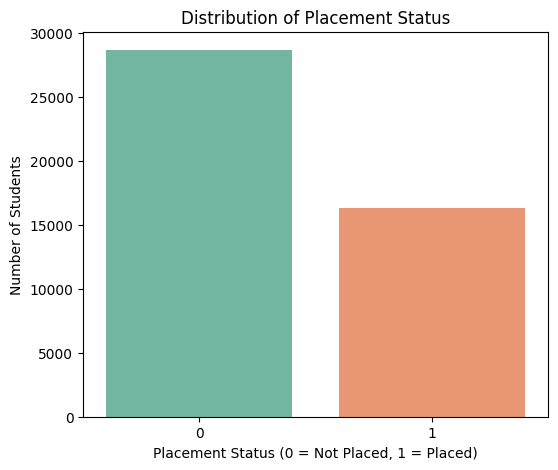

In [9]:
# BAR CHART - Placement Status Distribution
plt.figure(figsize=(6,5))

sns.countplot(x='Placement_Status', data=df, palette='Set2')

plt.title("Distribution of Placement Status")
plt.xlabel("Placement Status (0 = Not Placed, 1 = Placed)")
plt.ylabel("Number of Students")

plt.show()

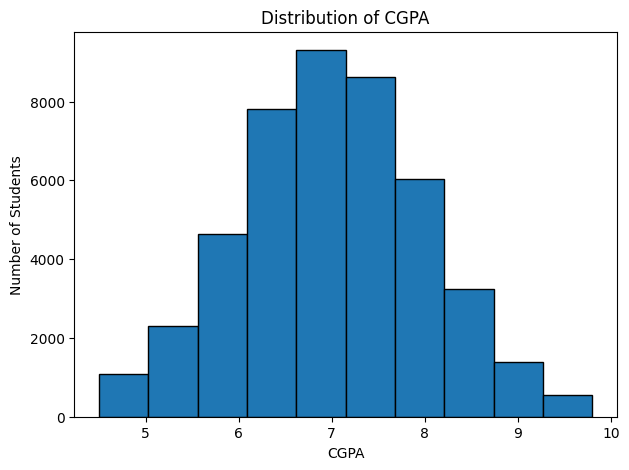

In [10]:
# HISTOGRAM - CGPA Distribution

plt.figure(figsize=(7,5))

plt.hist(df['CGPA'], bins=10, edgecolor='black')

plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.show()

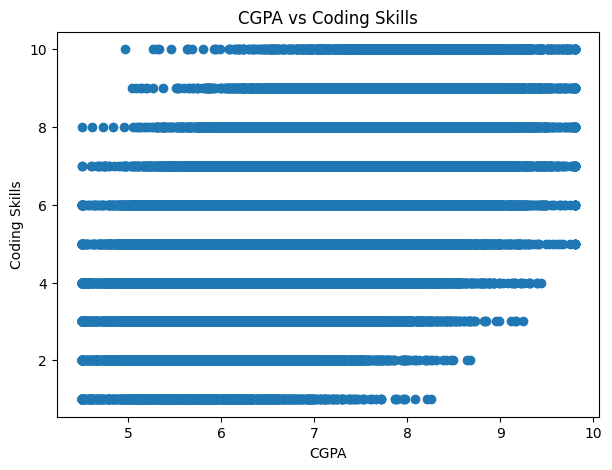

In [11]:
# SCATTER PLOT - CGPA vs Coding Skills
plt.figure(figsize=(7,5))

plt.scatter(df['CGPA'], df['Coding_Skills'])

plt.title("CGPA vs Coding Skills")
plt.xlabel("CGPA")
plt.ylabel("Coding Skills")

plt.show()

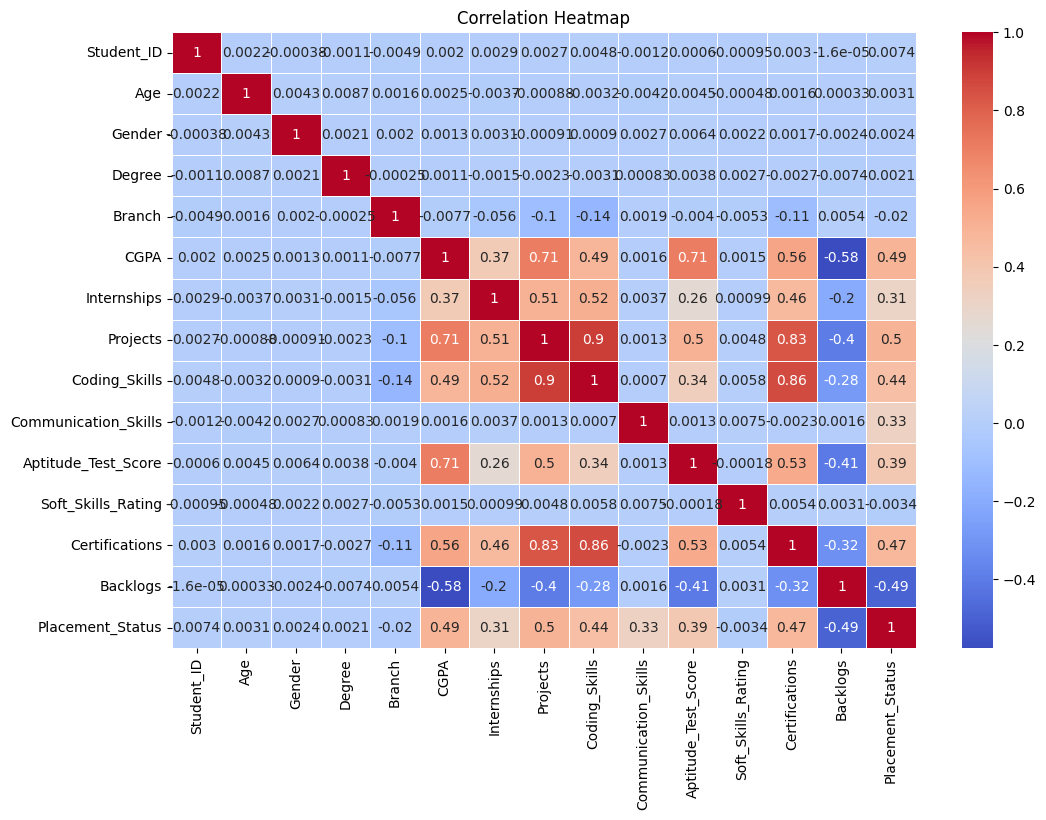

In [12]:
# HEATMAP - Correlation Matrix
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

In [13]:

# SELECT FEATURES AND TARGET VARIABLE

# Drop Student_ID because it does not help in prediction
X = df.drop(['Student_ID', 'Placement_Status'], axis=1)

# Target variable
y = df['Placement_Status']

# Display feature names
print("Features:")
print(X.columns)

Features:
Index(['Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects',
       'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score',
       'Soft_Skills_Rating', 'Certifications', 'Backlogs'],
      dtype='object')


In [14]:

# SPLIT DATA INTO TRAINING AND TESTING SETS

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (36000, 13)
Testing Data Shape: (9000, 13)


In [15]:

# TRAIN LOGISTIC REGRESSION MODEL

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [22]:
import joblib

joblib.dump(model, "placement_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [16]:

# MAKE PREDICTIONS

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[1 0 1 ... 0 0 0]


In [17]:

# MODEL ACCURACY

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 86.39 %


Confusion Matrix:
[[5132  577]
 [ 648 2643]]


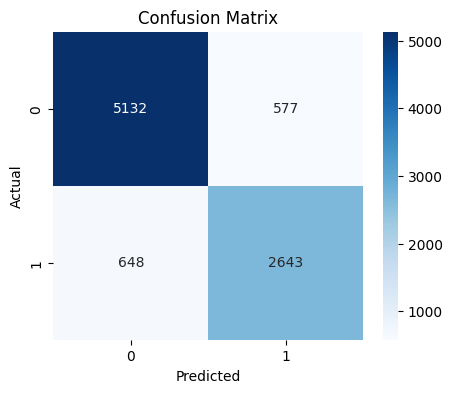

In [18]:

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:

# CLASSIFICATION REPORT

report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      5709
           1       0.82      0.80      0.81      3291

    accuracy                           0.86      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.86      0.86      0.86      9000



In [20]:

# FEATURE COEFFICIENTS

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print(coefficients)

                 Feature  Coefficient
11        Certifications     1.429256
8   Communication_Skills     1.085939
4                   CGPA     0.381761
6               Projects     0.313210
7          Coding_Skills     0.178303
5            Internships     0.133896
3                 Branch     0.055188
9    Aptitude_Test_Score     0.012965
0                    Age     0.011503
1                 Gender     0.008735
2                 Degree     0.005964
10    Soft_Skills_Rating    -0.045544
12              Backlogs    -1.885442


In [21]:

# PREDICT PLACEMENT FOR A NEW STUDENT

# Example student data
new_student = pd.DataFrame({
    'Age': [22],
    'Gender': [1],
    'Degree': [0],
    'Branch': [2],
    'CGPA': [7.3],
    'Internships': [1],
    'Projects': [1],
    'Coding_Skills': [7],
    'Communication_Skills': [8],
    'Aptitude_Test_Score': [60],
    'Soft_Skills_Rating': [7],
    'Certifications': [1],
    'Backlogs': [1]
})

# Predict Placement
prediction = model.predict(new_student)

# Predict Probability
probability = model.predict_proba(new_student)

placement_chance = probability[0][1] * 100
print("========== PLACEMENT PREDICTOR ==========")
print(f"Placement Chance : {placement_chance:.2f}%")

if placement_chance >= 80:
    print("Excellent Chances of Placement ")
elif placement_chance >= 60:
    print("Good Chances of Placement ")
elif placement_chance >= 40:
    print("Average Chances ")
else:
    print("Low Chances of Placement ")

if prediction[0] == 1:
    print("Prediction:Student is likely to be PLACED")
else:
    print("Prediction:Student is NOT likely to be placed")

========== PLACEMENT PREDICTOR ==========
Placement Chance : 28.66%
Low Chances of Placement 
Prediction:Student is NOT likely to be placed


In [23]:
import joblib

loaded_model = joblib.load("placement_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [24]:
import joblib
import pandas as pd

# Load saved model
loaded_model = joblib.load("placement_model.pkl")

# Example student
new_student = pd.DataFrame([[
    22,      # Age
    1,       # Gender
    0,       # Degree
    2,       # Branch
    8.5,     # CGPA
    1,       # Internships
    2,       # Projects
    8,       # Coding_Skills
    8,       # Communication_Skills
    75,      # Aptitude_Test_Score
    8,       # Soft_Skills_Rating
    2,       # Certifications
    0        # Backlogs
]], columns=[
    'Age',
    'Gender',
    'Degree',
    'Branch',
    'CGPA',
    'Internships',
    'Projects',
    'Coding_Skills',
    'Communication_Skills',
    'Aptitude_Test_Score',
    'Soft_Skills_Rating',
    'Certifications',
    'Backlogs'
])

prediction = loaded_model.predict(new_student)

print("Prediction:", prediction)

Prediction: [1]
